In [ ]:
## Instalar paquetes

In [39]:
pip install shap



   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [21]:
pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 613.7 kB/s eta 0:01:53
   ---------------------------------------- 0.5/69.5 MB 613.7 kB/s eta 0:01:53
   ---------------------------------------- 0.8/69.5 MB 646.3 kB/s eta 0:01:47
    --------------------------------------- 1.0/69.5 MB 724.3 kB/s eta 0:01:35
    --------------------------------------- 1.0/69.5 M

Librerías a usar

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier

**Análisis Exploratorio de Datos (EDA)**

In [1]:
import pandas as pd

# Cargar el dataset (ajusta la ruta según tus carpetas locales)
df = pd.read_csv("base_diabetes.csv")

# 1. Dimensiones de la matriz
print(f"Dimensiones: {df.shape}")

# 2. Verificar tipos de datos y nulos
info_df = pd.DataFrame({
    'Tipo de Dato': df.dtypes,
    'Valores Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df)) * 100
})
print(info_df)

Dimensiones: (253680, 22)
                     Tipo de Dato  Valores Nulos  % Nulos
Diabetes_012              float64              0      0.0
HighBP                    float64              0      0.0
HighChol                  float64              0      0.0
CholCheck                 float64              0      0.0
BMI                       float64              0      0.0
Smoker                    float64              0      0.0
Stroke                    float64              0      0.0
HeartDiseaseorAttack      float64              0      0.0
PhysActivity              float64              0      0.0
Fruits                    float64              0      0.0
Veggies                   float64              0      0.0
HvyAlcoholConsump         float64              0      0.0
AnyHealthcare             float64              0      0.0
NoDocbcCost               float64              0      0.0
GenHlth                   float64              0      0.0
MentHlth                  float64             

count    253680.000000
mean         28.382364
std           6.608694
min          12.000000
25%          24.000000
50%          27.000000
75%          31.000000
max          98.000000
Name: BMI, dtype: float64


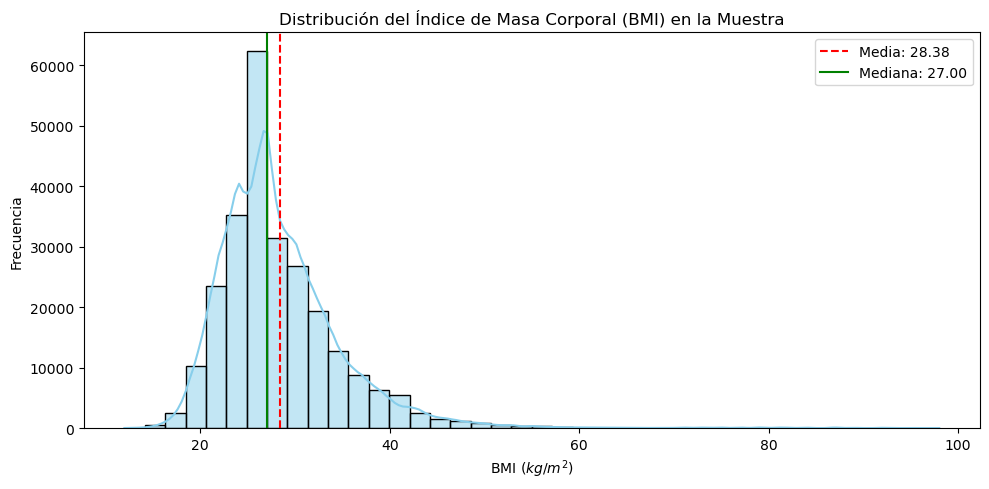

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Estadísticos descriptivos del BMI
print(df['BMI'].describe())

# 2. Generar el gráfico de distribución (Histograma + Boxplot)
plt.figure(figsize=(10, 5))
sns.histplot(df['BMI'], bins=40, kde=True, color='skyblue')
plt.axvline(df['BMI'].mean(), color='red', linestyle='--', label=f"Media: {df['BMI'].mean():.2f}")
plt.axvline(df['BMI'].median(), color='green', linestyle='-', label=f"Mediana: {df['BMI'].median():.2f}")
plt.title('Distribución del Índice de Masa Corporal (BMI) en la Muestra')
plt.xlabel('BMI ($kg/m^2$)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.savefig('distribucion_bmi.png', dpi=300, bbox_inches='tight')
plt.show()

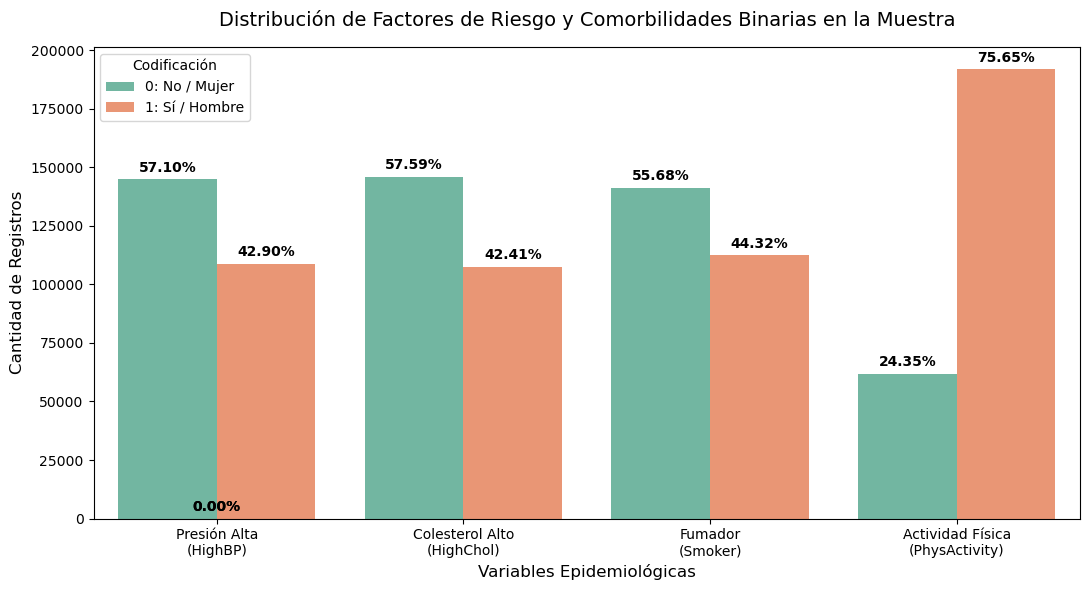

In [7]:
# Calcular las proporciones de las comorbilidades clave
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Seleccionar las variables binarias clave para graficar
variables_binarias = ['HighBP', 'HighChol', 'Smoker', 'PhysActivity']

# Crear un dataframe largo para facilitar el ploteo con Seaborn
df_melted = pd.melt(df[variables_binarias])

# Configurar el gráfico de barras
plt.figure(figsize=(11, 6))
ax = sns.countplot(data=df_melted, x='variable', hue='value', palette='Set2')

# Configurar textos y estética
plt.title('Distribución de Factores de Riesgo y Comorbilidades Binarias en la Muestra', fontsize=14, pad=15)
plt.xlabel('Variables Epidemiológicas', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3], labels=['Presión Alta\n(HighBP)', 'Colesterol Alto\n(HighChol)', 'Fumador\n(Smoker)', 'Actividad Física\n(PhysActivity)'])
plt.legend(title='Codificación', labels=['0: No / Mujer', '1: Sí / Hombre'])

# Añadir etiquetas de porcentaje sobre las barras para máxima legibilidad
total_filas = len(df)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total_filas:.2f}%'
    x_pos = p.get_x() + p.get_width() / 2
    y_pos = p.get_height() + 2000
    ax.annotate(porcentaje, (x_pos, y_pos), ha='center', va='bottom', fontsize=10, weight='bold')

plt.tight_layout()
plt.savefig('categoricas', dpi=300, bbox_inches='tight')
plt.show()

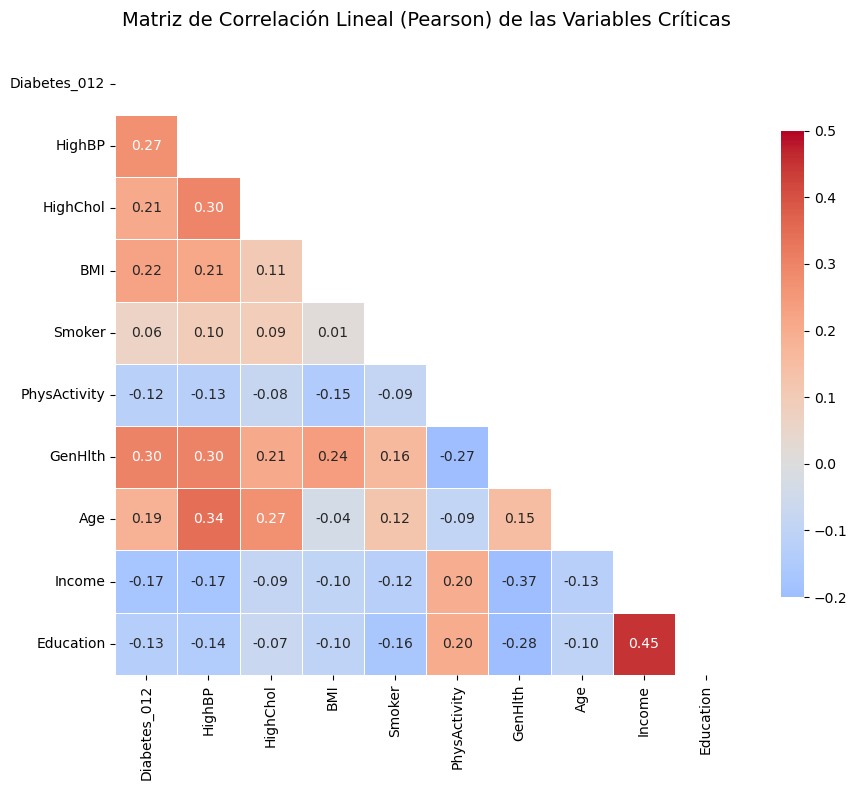

In [10]:
#matriz
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Seleccionar un subconjunto de las variables más críticas para que el gráfico sea legible y estético
variables_clave = ['Diabetes_012', 'HighBP', 'HighChol', 'BMI', 'Smoker', 
                   'PhysActivity', 'GenHlth', 'Age', 'Income', 'Education']

# Calcular la matriz de correlación
corr_matrix = df[variables_clave].corr()

# Configurar el lienzo
plt.figure(figsize=(10, 8))

# Generar una máscara para ocultar la mitad superior (triángulo superior) y que se vea más profesional
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Dibujar el mapa de calor
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=0.5, vmin=-0.2, center=0, square=True, linewidths=.5, 
            cbar_kws={"shrink": .75})

plt.title('Matriz de Correlación Lineal (Pearson) de las Variables Críticas', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('matrizcon', dpi=300, bbox_inches='tight')
plt.show()

**1.- PREPROCESAMIENTO** 

In [48]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

In [25]:
# Configuración estética para los gráficos 
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

In [5]:
# 1. CARGA DEL DATASET
# Usamos el archivo de Kaggle de Alex Teboul (BRFSS 2015)
df = pd.read_csv("base_diabetes.csv")

In [7]:
print("--- 1. PRIMER VISTAZO A LOS DATOS ---")
print(f"Cantidad total de registros (Filas): {df.shape[0]:,}")
print(f"Cantidad de variables analizadas (Columnas): {df.shape[1]}")

print("\n--- 2. VERIFICACIÓN DE CALIDAD DE DATOS (NULOS Y TIPOS) ---")
# Esto demuestra que controlamos la calidad antes de modelar
info_datos = pd.DataFrame({
    'Tipo de Dato': df.dtypes,
    'Valores Nulos': df.isnull().sum(),
    'Valores Únicos': df.nunique()
})
print(info_datos)

--- 1. PRIMER VISTAZO A LOS DATOS ---
Cantidad total de registros (Filas): 253,680
Cantidad de variables analizadas (Columnas): 22

--- 2. VERIFICACIÓN DE CALIDAD DE DATOS (NULOS Y TIPOS) ---
                     Tipo de Dato  Valores Nulos  Valores Únicos
Diabetes_012              float64              0               3
HighBP                    float64              0               2
HighChol                  float64              0               2
CholCheck                 float64              0               2
BMI                       float64              0              84
Smoker                    float64              0               2
Stroke                    float64              0               2
HeartDiseaseorAttack      float64              0               2
PhysActivity              float64              0               2
Fruits                    float64              0               2
Veggies                   float64              0               2
HvyAlcoholConsump         fl

In [6]:
df.head(5)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [10]:
print("\n--- 2. ANÁLISIS DE LA VARIABLE OBJETIVO MULTICLASE (Diabetes_012) ---")
conteo_clases = df['Diabetes_012'].value_counts()
porcentaje_clases = df['Diabetes_012'].value_counts(normalize=True) * 100

df_target = pd.DataFrame({
    'Significado': ['No Diabetes (0)', 'Diabetes (2)', 'Prediabetes (1)'], # Reordenado según el conteo real
    'Casos de la muestra': conteo_clases,
    'Porcentaje (%)': porcentaje_clases
})
print(df_target.to_string())


--- 2. ANÁLISIS DE LA VARIABLE OBJETIVO MULTICLASE (Diabetes_012) ---
                  Significado  Casos de la muestra  Porcentaje (%)
Diabetes_012                                                      
0.0           No Diabetes (0)               213703       84.241170
2.0              Diabetes (2)                35346       13.933302
1.0           Prediabetes (1)                 4631        1.825528


C:\Users\DELL\AppData\Local\Temp\ipykernel_29388\640566774.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df_target['Significado'], y=df_target['Casos de la muestra'], palette='viridis')


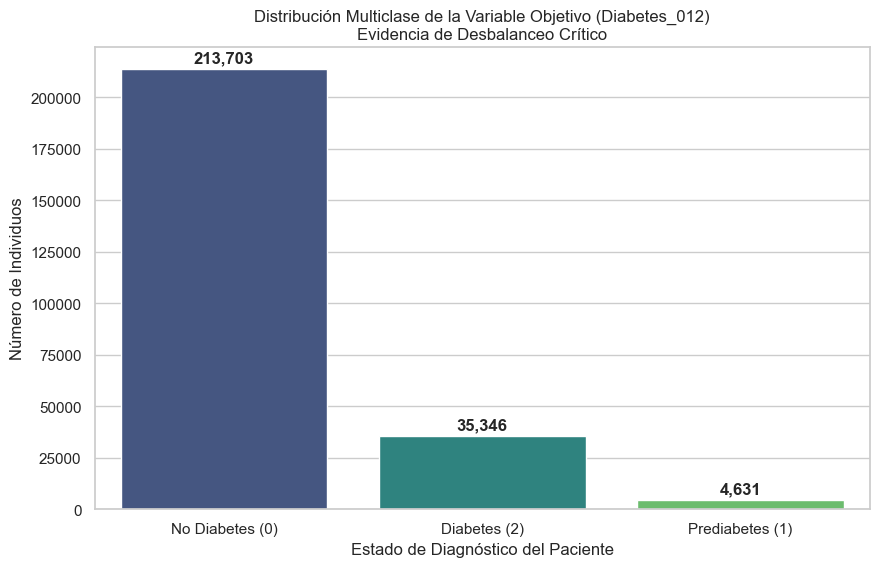

In [11]:
# Gráfico 1: Desbalanceo real en problemas de salud multiclase
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=df_target['Significado'], y=df_target['Casos de la muestra'], palette='viridis')
plt.title('Distribución Multiclase de la Variable Objetivo (Diabetes_012)\nEvidencia de Desbalanceo Crítico')
plt.ylabel('Número de Individuos')
plt.xlabel('Estado de Diagnóstico del Paciente')
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', weight='bold')
plt.savefig('51_distribucion_clases.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
print("\n--- 4. COMPROBACIÓN ÉTICA Y CALIDAD (VALORES NULOS) ---")
print(f"Valores nulos totales en el dataset: {df.isnull().sum().sum()}")


--- 4. COMPROBACIÓN ÉTICA Y CALIDAD (VALORES NULOS) ---
Valores nulos totales en el dataset: 0
